In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Ensure the project root is in the Python path for module imports
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from cd_poly.cd_poly import *

In [4]:
IMAGE_SIZE = 28 * 28  # MNIST image dimensions
LATENT_DIM = 10      # Dimension of the latent space
BATCH_SIZE = 256
LEARNING_RATE = 8e-3
NUM_EPOCHS = 50
DEVICE = torch.device("mps" if torch.mps.is_available() else "cpu")

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

full_mnist_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

indices_3s_7s = []
for i, (image, label) in enumerate(full_mnist_train_dataset):
    if label == 3 or label == 7:
        indices_3s_7s.append(i)

train_ds = Subset(full_mnist_train_dataset, indices_3s_7s)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

In [6]:
class AutoencoderCNN(nn.Module):
    def __init__(self, input_channels=1, latent_dim=64):
        super(AutoencoderCNN, self).__init__()

        # Encoder
        # Input: [batch_size, 1, 28, 28]
        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 2, kernel_size=3, stride=2, padding=1), # Output: [batch_size, 2, 14, 14]
            nn.ReLU(),
            nn.Conv2d(2, 4, kernel_size=3, stride=2, padding=1),  # Output: [batch_size, 4, 7, 7]
            nn.ReLU(),
            nn.Conv2d(4, 8, kernel_size=3, stride=2, padding=1), # Output: [batch_size, 8, 4, 4] (approx)
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1), # Output: [batch_size, 16, 2, 2] (approx)
            nn.ReLU(),
            nn.Flatten(), # Flatten for the latent space
            nn.Linear(16 * 2 * 2, latent_dim) # Adjust this if output of last conv changes
        )

        # Decoder
        # Input: [batch_size, latent_dim]
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16 * 2 * 2), # Reshape back to convolutional dimensions
            nn.ReLU(),
            nn.Unflatten(1, (16, 2, 2)),
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: [batch_size, 4, 7, 7]
            nn.ReLU(),
            nn.ConvTranspose2d(8, 4, kernel_size=3, stride=2, padding=1, output_padding=0), # Output: [batch_size, 4, 7, 7]
            nn.ReLU(),
            nn.ConvTranspose2d(4, 2, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: [batch_size, 2, 14, 14]
            nn.ReLU(),
            nn.ConvTranspose2d(2, input_channels, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: [batch_size, 1, 28, 28]
            nn.Sigmoid() # Sigmoid to output pixel values between 0 and 1
        )

    def forward(self, x):
        # Ensure input is reshaped for CNN: [batch_size, channels, height, width]
        # MNIST images are typically 28x28, 1 channel

        enc = self.encoder(x)
        dec = self.decoder(enc)
        return dec, enc

In [7]:
model = AutoencoderCNN(input_channels=1, latent_dim=LATENT_DIM).to(DEVICE)
criterion = nn.MSELoss() # Mean Squared Error for reconstruction
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

sum(p.numel() for p in model.parameters() if p.requires_grad)

4459

In [15]:
losses = []

for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for batch_idx, (data, _) in enumerate(train_dl):
        # Flatten the images and move to device
        data = data.to(DEVICE)

        # Forward pass
        rec, enc = model(data)
        loss = criterion(rec, data)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.size(0)

    avg_loss = total_loss / len(train_dl.dataset)
    losses.append(avg_loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {avg_loss:.4f}")

print("Training finished.")

Epoch [5/50], Loss: 0.0624
Epoch [10/50], Loss: 0.0440
Epoch [15/50], Loss: 0.0365
Epoch [20/50], Loss: 0.0319
Epoch [25/50], Loss: 0.0281
Epoch [30/50], Loss: 0.0263
Epoch [35/50], Loss: 0.0251
Epoch [40/50], Loss: 0.0242
Epoch [45/50], Loss: 0.0232
Epoch [50/50], Loss: 0.0226
Training finished.


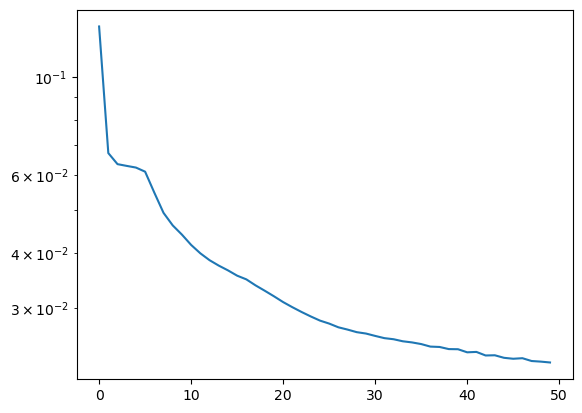

In [16]:
plt.plot(losses)
plt.yscale('log')

In [21]:
save_path = 'mnist.pth'
if not os.path.exists(save_path):
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to '{save_path}'")
else:
    print(f"Model already exists at '{save_path}'; not overwriting.")

Model saved to 'mnist.pth'


In [8]:
# load if needed
model = AutoencoderCNN(latent_dim=10).to(DEVICE)
model.load_state_dict(torch.load('mnist.pth'))

<All keys matched successfully>

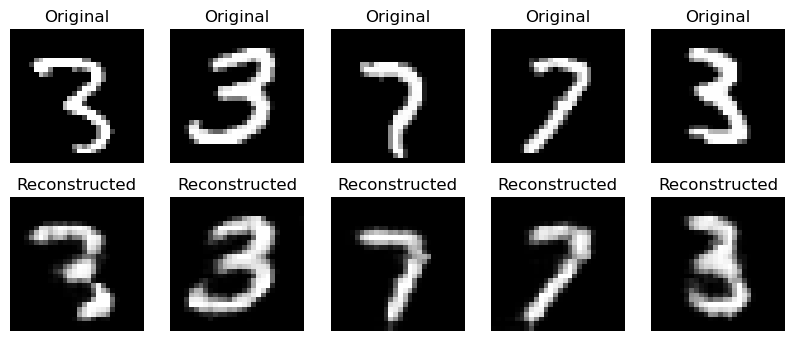

In [12]:
model.eval()
with torch.no_grad():
    sample_data, _ = next(iter(train_dl))
    sample_data = sample_data.to(DEVICE)
    rec, _ = model(sample_data)
    rec = rec.cpu()
    original_samples = sample_data.cpu()

    plt.figure(figsize=(10, 4))
    for i in range(5):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(original_samples[i].squeeze(), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        ax = plt.subplot(2, 5, i + 6)
        plt.imshow(rec[i].squeeze(), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
    plt.show()

In [13]:
indices_5s = []
for i, (image, label) in enumerate(full_mnist_train_dataset):
    if label == 5:
        indices_5s.append(i)

ds_5s = Subset(full_mnist_train_dataset, indices_5s)
dl_5s = DataLoader(ds_5s, batch_size=BATCH_SIZE)


In [14]:
it = iter(train_dl)
latents = []
labels = []
for i in range(10):
    samples_x, samples_y = next(it)
    model.eval()
    with torch.no_grad():
        rec, enc = model(samples_x.to(DEVICE))
    latents.append(enc.to('cpu').numpy())
    labels.append(samples_y.to('cpu').numpy())
latents = np.concat(latents)
labels = np.concat(labels)

In [20]:
it = iter(dl_5s)
latents_5s = []
labels_5s = []
X_5s = []
for i in range(10):
    samples_x, samples_y = next(it)
    model.eval()
    with torch.no_grad():
        rec, enc = model(samples_x.to(DEVICE))
    latents_5s.append(enc.to('cpu').numpy())
    labels_5s.append(samples_y.to('cpu').numpy())
    X_5s.append(samples_x)
latents_5s = np.concat(latents_5s)
labels_5s = np.concat(labels_5s)
X_5s = np.concat(X_5s)

In [22]:
latents.shape, latents_5s.shape

((2560, 10), (2560, 10))

In [23]:
p = CDPolynomial(latents, degree=4, verbose=True)

Data monomials shape: (2560, 1001)
Moment matrix cond num: 7.144278e+14
Empirical mean of CD poly: 1000.9999999999993


287.11825901852836
1412847.9048580686


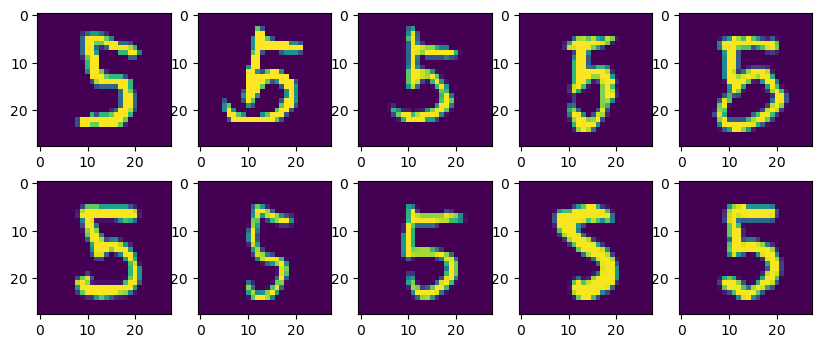

In [42]:
print(p(latents_5s).min()), print(p(latents_5s).max())

fig, ax = plt.subplots(2, 5, figsize=(10, 4))
low_val_idx = np.argsort(p(latents_5s))[:10]
for idx, i in enumerate(low_val_idx):
    ax[idx//5, idx%5].imshow(X_5s[i, 0])

In [44]:
latents.shape

(2560, 10)

In [ ]:
p

Text(0.5, 1.0, 'Accuracy on outlier detection')

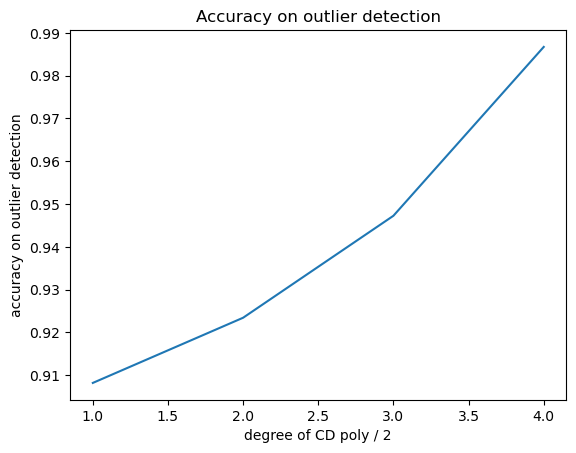

In [43]:
acc = []
for i in range(1, 5):
    p = CDPolynomial(latents, degree=i, verbose=False)
    acc.append((p(latents_5s) > p.mean).mean())

plt.plot(range(1, 5), acc)
plt.xlabel('degree of CD poly / 2')
plt.ylabel('accuracy on outlier detection')
plt.title('Accuracy on outlier detection')

Outlier detection methods:
- one-class SVM
- look at reconstruction error of AE
- some kind of contrastive learning based on synthetic failure data
- clustering + distance

In [106]:
from sklearn.svm import OneClassSVM

In [107]:
oc_svm = OneClassSVM(kernel='rbf', nu=0.0001)

oc_svm.fit(latents)

OneClassSVM(nu=0.0001)

In [109]:
oc_svm_pred = oc_svm.predict(latents_5s)

(oc_svm_pred == 1).sum() / len(latents_5s)

np.float64(0.9609375)